# __Predicting Fast-Charging Availability at EV Charging Locations__

---

## __PROBLEM STATEMENT__

* The global EV charging network is expanding fast, but not every location is built the same way — some sites are tiny single-plug setups, while others are large multi-port hubs.

* A big question for planners, investors, and EV drivers alike is: **can we tell, just from the size and location of a charging site, whether it is likely to offer fast DC charging?**

* This matters in real life because power-rating information is often missing or unverified in early-stage datasets (new sites, crowd-sourced listings, incomplete government records), while the *footprint* of a site — how many stations, how many ports, and where it is — is usually known right away.

* In this notebook, we treat this as a **binary classification problem**: predict the target column `has_fast_dc` (1 = the location has at least one DC fast charger, 0 = it does not) using only footprint and location features, **without using any column that leaks the answer** (such as power ratings or fast-station counts, which by definition already encode the label).

* We will build, compare, and tune multiple classification models to find the one that generalizes best to unseen charging locations.

---

## __OBJECTIVE__

* Perform thorough data cleaning and preprocessing on the raw charging station dataset.
* Explore the data visually to understand patterns in infrastructure size, geography, and fast-charging adoption.
* Engineer meaningful features and prepare the data for modeling.
* Train **multiple classification algorithms in a loop**, evaluate them on common metrics, and compare results.
* Perform **hyperparameter tuning** on the strongest candidates to squeeze out extra performance.
* Select and evaluate the final model, and summarize business-relevant takeaways.

## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

pd.set_option('display.max_columns', None)

### Loading Dataset and Initial Exploration

In [3]:
df = pd.read_csv("charging_station_ml.csv")
print("Shape of the dataset :", df.shape)
df.sample(10)

Shape of the dataset : (58642, 18)


,country_code,country,state_province,city,latitude,longitude,station_count,port_count,fast_station_count,fast_port_count,fast_station_share,fast_port_share,max_power_kw,median_power_kw,dc_fast_station_count,dc_ultra_station_count,has_fast_dc,has_ultra_dc
7353,DE,Germany,Bargteheide-Land,Tremsbüttel,53.744220,10.312480,1,3,0,0,0.000000,0.000000,11.0,11.00,0,0,0,0
27961,GB,United Kingdom,UNKNOWN,Aylesbury,51.826637,-0.861946,10,18,2,2,0.200000,0.111111,50.0,7.00,2,0,1,0
36698,IT,Italy,UNKNOWN,Acciaroli di Pollica,40.181988,15.025337,1,1,0,0,0.000000,0.000000,11.0,11.00,0,0,0,0
38263,LU,Luxembourg,UNKNOWN,Itzig,49.587155,6.170041,1,1,0,0,0.000000,0.000000,11.0,11.00,0,0,0,0
46045,TR,Turkey,Osmaniye,Osmaniye,37.051381,36.229483,3,5,2,4,0.666667,0.800000,120.0,120.00,2,0,1,0
6392,CH,Switzerland,UNKNOWN,Sierre,46.292029,7.529888,2,3,0,0,0.000000,0.000000,22.0,16.50,0,0,0,0
54375,US,United States,NY,Saratoga,43.100931,-73.762131,2,2,1,1,0.500000,0.500000,50.0,26.85,1,0,1,0
3437,CA,Canada,British Columbia,Nelson,49.497254,-117.293984,1,1,0,0,0.000000,0.000000,16.0,16.00,0,0,0,0
11646,DE,Germany,UNKNOWN,Dauchingen,48.091639,8.555522,1,1,0,0,0.000000,0.000000,22.0,22.00,0,0,0,0
20070,ES,Spain,UNKNOWN,Pacs del Penedes,41.349488,1.666273,1,2,0,0,0.000000,0.000000,22.0,22.00,0,0,0,0


## Columns Overview :

In [4]:
info_df = pd.DataFrame({
    "dtype"           : df.dtypes,
    "non_null "       : df.notnull().sum(),
    "null_count "     : df.isnull().sum(),
    "null_percentage" : (df.isnull().mean() * 100).round(2)
})
display(info_df)

,dtype,non_null,null_count,null_percentage
country_code,object,58642,0,0.00
country,object,58642,0,0.00
state_province,object,58642,0,0.00
city,object,58642,0,0.00
latitude,float64,58642,0,0.00
longitude,float64,58642,0,0.00
station_count,int64,58642,0,0.00
port_count,int64,58642,0,0.00
fast_station_count,int64,58642,0,0.00
fast_port_count,int64,58642,0,0.00


In [5]:
print("\n NUMERIC SUMMARY  -")
display(df.describe().T.round(2))


 NUMERIC SUMMARY  -


,count,mean,std,min,25%,50%,75%,max
latitude,58642.0,42.63,17.60,-55.81,40.27,46.14,51.47,81.74
longitude,58642.0,-11.99,55.37,-164.85,-69.84,2.29,11.50,178.37
station_count,58642.0,4.13,55.38,1.00,1.00,1.00,2.00,10354.00
port_count,58642.0,8.10,72.01,-4.00,1.00,2.00,6.00,10594.00
fast_station_count,58642.0,0.87,4.23,0.00,0.00,0.00,1.00,446.00
fast_port_count,58642.0,2.53,15.98,0.00,0.00,0.00,2.00,2126.00
fast_station_share,58642.0,0.30,0.41,0.00,0.00,0.00,0.60,1.00
fast_port_share,58638.0,0.31,0.42,0.00,0.00,0.00,0.75,1.00
max_power_kw,56902.0,79.29,4192.76,0.00,11.00,22.00,50.00,1000000.00
median_power_kw,56902.0,57.66,4192.41,0.00,7.20,22.00,50.00,1000000.00


### A quick read of the summary table
* `station_count` and `port_count` are heavily right-skewed — most locations have just 1-2 stations, but a few "mega-hubs" have thousands.
* `max_power_kw` has an obviously broken value (max = 1,000,000 kW) — a single data-entry error we'll need to fix.
* `port_count` even dips into **negative territory**, which is physically impossible and needs cleaning.
* The target column `has_fast_dc` is binary (0/1), which confirms this is a classification problem.

## Data Cleaning and Preprocessing :

#### Fixing impossible / broken values

In [6]:
print(f"Original dataset size: {df.shape[0]} rows")

# 1. Port count cannot be zero or negative - these are data-entry errors (only a handful of rows)
df = df[df['port_count'] > 0]

# 2. Domain Knowledge Filter: a 1,000,000 kW charger does not exist - remove impossible power readings
df = df[(df['max_power_kw'] <= 1500) | (df['max_power_kw'].isna())]

print(f"Dataset size after fixing broken values: {df.shape[0]} rows")

Original dataset size: 58642 rows
Dataset size after fixing broken values: 58636 rows


#### Taming extreme outliers in station size (capping at the 99th percentile)

In [7]:
# station_count / port_count have a very long tail (a few mega-hubs with thousands of ports).
# Instead of deleting these rows (and losing real locations), we cap them at the 99th percentile
# so a handful of extreme outliers don't dominate distance-based models like KNN and SVM.

for col in ['station_count', 'port_count']:
    cap_value = df[col].quantile(0.99)
    df[col] = np.where(df[col] > cap_value, cap_value, df[col])
    print(f"{col:15s} capped at the 99th percentile -> {cap_value:.1f}")

station_count   capped at the 99th percentile -> 40.0
port_count      capped at the 99th percentile -> 80.0


#### Filling null values using median :

In [8]:
power_cols = ['fast_port_share', 'max_power_kw', 'median_power_kw']
df[power_cols] = df[power_cols].fillna(df[power_cols].median())

print("Remaining nulls after imputation:")
print(df.isnull().sum().sum())

Remaining nulls after imputation:
0


#### Checking for duplicate rows

In [9]:
print("Duplicate rows :", df.duplicated().sum())

Duplicate rows : 0


#### Dropping columns we won't use for modeling
* `country_code` — we already have the full `country` name.
* `state_province` and `city` — thousands of unique values each, too sparse to be useful without heavy target-encoding, and not needed once we keep `latitude`/`longitude` for location.

In [10]:
df.drop(columns=['country_code', 'state_province', 'city'], inplace=True)
df.reset_index(drop=True, inplace=True)
df.shape

(58636, 15)

## Feature Engineering

In [11]:
# Ports per station tells us whether a location is a "single plug" site or a multi-port hub
df['ports_per_station'] = df['port_count'] / df['station_count']

# Bucket countries so rare countries don't blow up the feature space with one-hot encoding
top_countries = df['country'].value_counts().head(10).index
df['country_group'] = df['country'].where(df['country'].isin(top_countries), 'Other')

df[['station_count', 'port_count', 'ports_per_station', 'country_group']].head()

,station_count,port_count,ports_per_station,country_group
0,2.0,4.0,2.0,Other
1,1.0,2.0,2.0,Other
2,1.0,2.0,2.0,Other
3,1.0,2.0,2.0,Other
4,2.0,3.0,1.5,Other


## Why Some Columns Cannot Be Used as Features (Target Leakage)

Before picking our final feature set, it's worth checking *how* the target column was actually created — this is a step that's easy to skip, but skipping it is exactly how you end up with a model that scores 99.9% accuracy and is completely useless in the real world.

In [12]:
# Does the target line up perfectly with any single column?
print("has_fast_dc  ==  (dc_fast_station_count > 0) :", (df['has_fast_dc'] == (df['dc_fast_station_count'] > 0).astype(int)).mean())
print("has_fast_dc  ==  (max_power_kw >= 50)         :", (df['has_fast_dc'] == (df['max_power_kw'] >= 50).astype(int)).mean())

has_fast_dc  ==  (dc_fast_station_count > 0) : 1.0
has_fast_dc  ==  (max_power_kw >= 50)         : 1.0


### Inference: We found leakage — and that's a good catch, not a bad result
* **`dc_fast_station_count`, `fast_station_count`, `fast_port_count`, `fast_station_share`, `fast_port_share`, `dc_ultra_station_count`, `has_ultra_dc`** are all *directly derived* from the same fast-charging definition as our target. Feeding these in would let the model "cheat" by looking up the answer instead of learning a pattern.
* Even more subtly, **`max_power_kw` and `median_power_kw` match `has_fast_dc` 100% of the time** — because "fast DC charging" is *defined* in this dataset as a station rated 50 kW or higher. Including power columns would turn this into a trivial threshold lookup, not a real prediction task.
* So we deliberately drop all of these columns and keep only the features that describe a location's **physical footprint and geography** — the information that's realistically available even when power specs are missing or not yet confirmed. This gives us a genuinely useful, non-trivial classification problem.

In [13]:
leakage_columns = [
    'fast_station_count', 'fast_port_count', 'fast_station_share', 'fast_port_share',
    'dc_fast_station_count', 'dc_ultra_station_count', 'has_ultra_dc',
    'max_power_kw', 'median_power_kw'
]
print("Columns dropped due to target leakage:")
for c in leakage_columns:
    print(" -", c)

Columns dropped due to target leakage:
 - fast_station_count
 - fast_port_count
 - fast_station_share
 - fast_port_share
 - dc_fast_station_count
 - dc_ultra_station_count
 - has_ultra_dc
 - max_power_kw
 - median_power_kw


---

# _EXPLORATORY DATA ANALYSIS_ :

## Target Variable Balance: Fast DC vs. No Fast DC

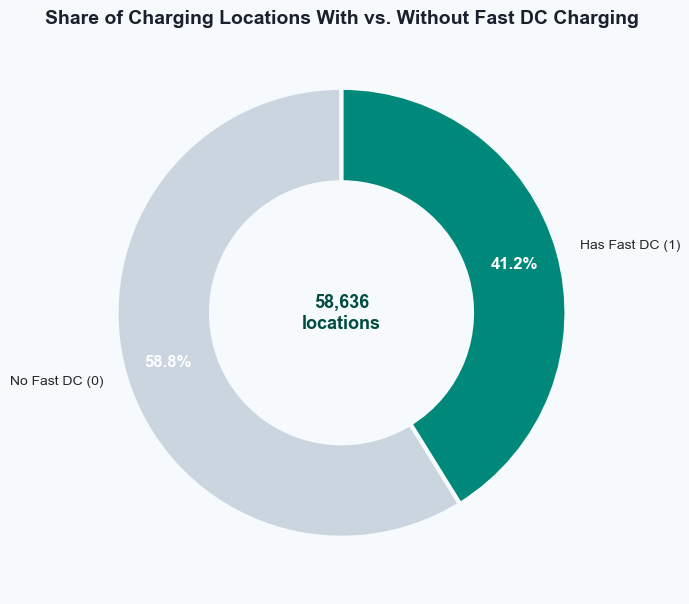

In [14]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(7, 7), dpi=100)
fig.patch.set_facecolor('#F7FAFC')

counts = df['has_fast_dc'].value_counts().sort_index()
labels = ['No Fast DC (0)', 'Has Fast DC (1)']
colors = ['#CBD5E0', '#00897B']

wedges, texts, autotexts = ax.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.80,
    wedgeprops={'width': 0.42, 'edgecolor': '#F7FAFC', 'linewidth': 3}
)
for t in autotexts:
    t.set_color('white')
    t.set_fontweight('bold')
    t.set_fontsize(12)

ax.set_title('Share of Charging Locations With vs. Without Fast DC Charging', fontsize=14, fontweight='bold', color='#1A202C')
ax.text(0, 0, f"{len(df):,}\nlocations", ha='center', va='center', fontsize=13, fontweight='bold', color='#004D40')
plt.tight_layout()
plt.show()

### Inference: A healthy, workable class balance
* Roughly **59% of charging locations don't have fast DC charging**, while **41% do** — this is close enough to balanced that we don't need special resampling tricks like SMOTE.
* This also tells us something practical: fast charging is still the minority setup worldwide, even though it's the more headline-grabbing technology.

## Station Footprint Size by Fast-Charging Status

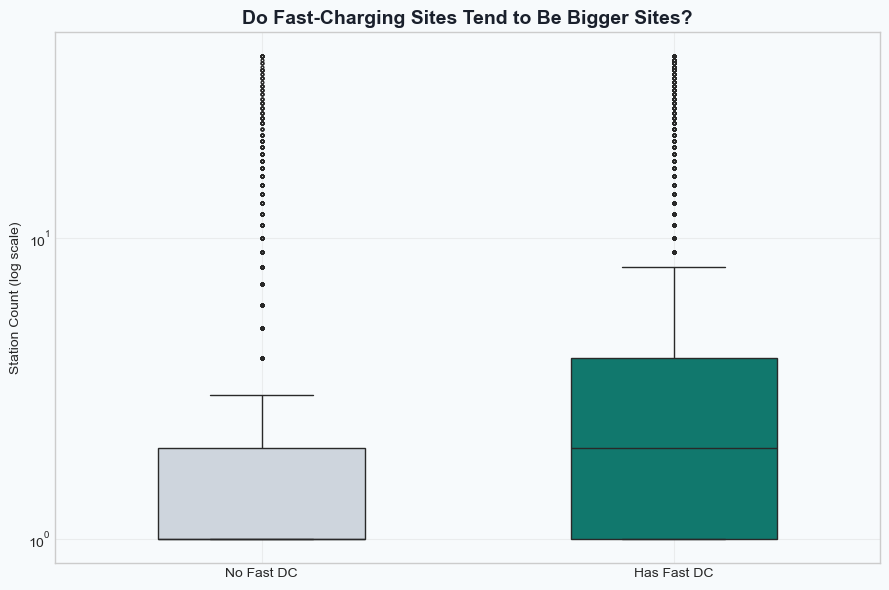

In [15]:
fig, ax = plt.subplots(figsize=(9, 6), dpi=100)
fig.patch.set_facecolor('#F7FAFC')
ax.set_facecolor('#F7FAFC')

sns.boxplot(
    data=df, x='has_fast_dc', y='station_count',
    hue='has_fast_dc', palette={0: '#CBD5E0', 1: '#00897B'},
    width=0.5, ax=ax, legend=False, fliersize=2
)

ax.set_yscale('log')
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Fast DC', 'Has Fast DC'])
ax.set_xlabel('')
ax.set_ylabel('Station Count (log scale)')
ax.set_title('Do Fast-Charging Sites Tend to Be Bigger Sites?', fontsize=14, fontweight='bold', color='#1A202C')
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

### Inference: Bigger sites lean towards fast charging
* Locations **with** fast DC charging tend to have a noticeably higher median `station_count` than locations without it.
* This makes intuitive sense — a bigger charging hub is more likely to be a planned, well-funded installation (like a highway rest stop or shopping mall), and those are exactly the kind of sites that get the fast-charging upgrade.
* Smaller, single-station sites (often home-style or workplace chargers) are far more likely to stick with slower AC charging.

## Ports-per-Station Density: Single Plug vs. Multi-Port Hubs

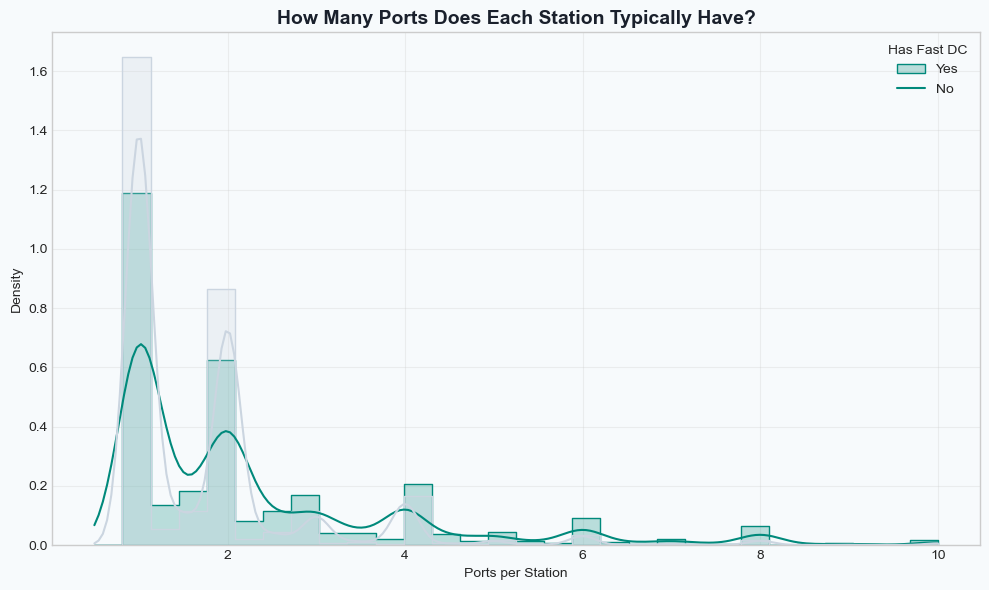

In [16]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
fig.patch.set_facecolor('#F7FAFC')
ax.set_facecolor('#F7FAFC')

sns.histplot(
    data=df[df['ports_per_station'] <= 10], x='ports_per_station', hue='has_fast_dc',
    palette={0: '#CBD5E0', 1: '#00897B'}, bins=30, kde=True,
    element='step', stat='density', common_norm=False, ax=ax
)

ax.set_xlabel('Ports per Station')
ax.set_ylabel('Density')
ax.set_title('How Many Ports Does Each Station Typically Have?', fontsize=14, fontweight='bold', color='#1A202C')
ax.legend(title='Has Fast DC', labels=['Yes', 'No'])
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

### Inference: Fast-charging sites pack in more ports per station
* Both groups peak around **1-2 ports per station**, which reflects most charging locations still being small setups.
* But the fast-DC group has a visibly fatter tail beyond 2-3 ports per station — these are the "charging plaza" style locations designed to serve several vehicles fast, one after another.
* This confirms `ports_per_station` is a genuinely useful signal for the model, not just noise.

## Fast-Charging Adoption Rate by Country (Top 12)

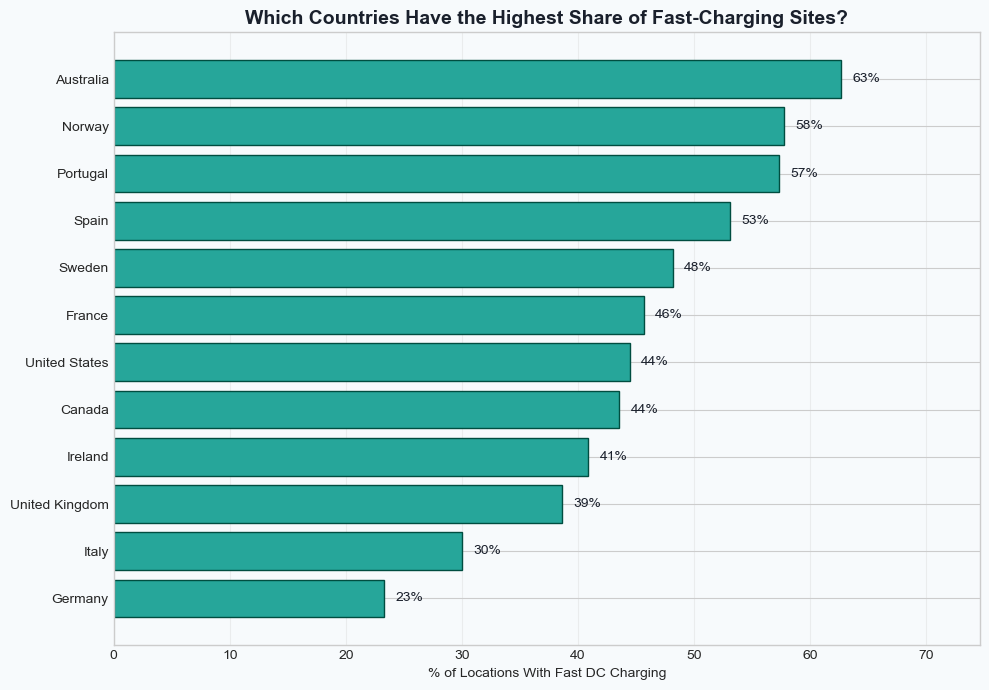

In [17]:
top12 = df['country'].value_counts().head(12).index
adoption = df[df['country'].isin(top12)].groupby('country')['has_fast_dc'].mean().sort_values(ascending=True) * 100

fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
fig.patch.set_facecolor('#F7FAFC')
ax.set_facecolor('#F7FAFC')

bars = ax.barh(adoption.index, adoption.values, color='#26A69A', edgecolor='#004D40')
for bar, v in zip(bars, adoption.values):
    ax.text(v + 1, bar.get_y() + bar.get_height()/2, f"{v:.0f}%", va='center', fontsize=10, color='#1A202C')

ax.set_xlabel('% of Locations With Fast DC Charging')
ax.set_title('Which Countries Have the Highest Share of Fast-Charging Sites?', fontsize=14, fontweight='bold', color='#1A202C')
ax.set_xlim(0, max(adoption.values) + 12)
ax.grid(alpha=.3, axis='x')
plt.tight_layout()
plt.show()

### Inference: Fast-charging adoption is very country-specific
* There's a wide spread between the top and bottom countries in our top-12 list — some markets have built fast charging into a much larger share of their network than others.
* This tells us `country` (and by extension geography) carries real predictive signal, so encoding it as a feature should genuinely help the model rather than just adding noise.
* It also hints at differing national strategies — some countries have prioritized volume (many slow chargers everywhere), while others prioritized speed (fewer, faster chargers on key routes).

## Station Count vs. Port Count, Colored by Fast-Charging Status

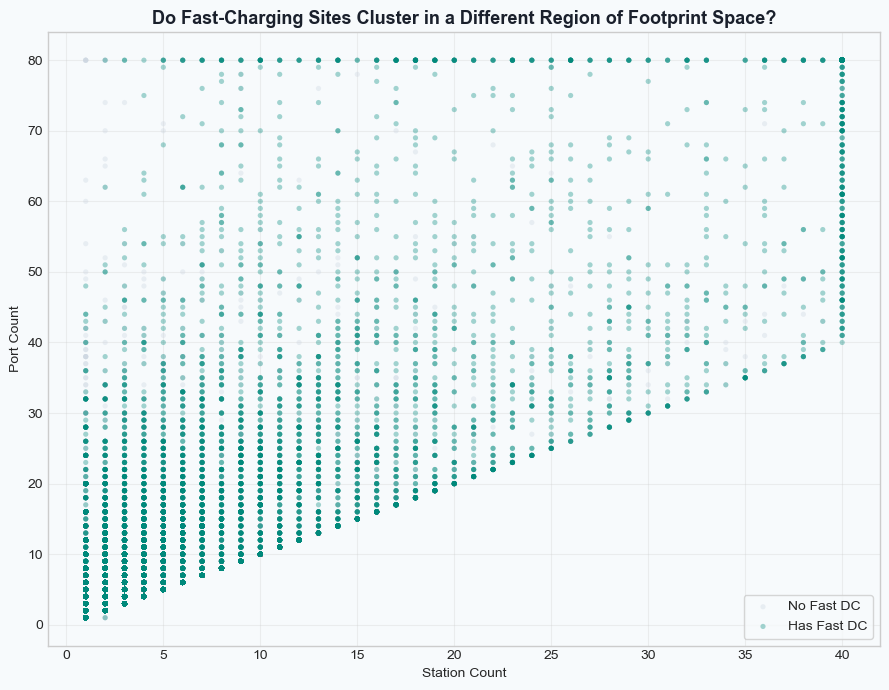

In [18]:
fig, ax = plt.subplots(figsize=(9, 7), dpi=100)
fig.patch.set_facecolor('#F7FAFC')
ax.set_facecolor('#F7FAFC')

for val, color, label in [(0, '#CBD5E0', 'No Fast DC'), (1, '#00897B', 'Has Fast DC')]:
    subset = df[df['has_fast_dc'] == val]
    ax.scatter(subset['station_count'], subset['port_count'], s=14, alpha=0.35, color=color, label=label, edgecolors='none')

ax.set_xlabel('Station Count')
ax.set_ylabel('Port Count')
ax.set_title('Do Fast-Charging Sites Cluster in a Different Region of Footprint Space?', fontsize=13, fontweight='bold', color='#1A202C')
ax.legend(frameon=True, facecolor='#F7FAFC')
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

### Inference: A visible (but not perfect) separation
* The teal points (fast DC) skew towards the upper-right of the plot — more stations *and* more ports — while the grey points (no fast DC) are dense near the bottom-left, i.e. small, single-plug locations.
* The overlap in the middle is exactly why this is a genuinely hard classification problem — there isn't a clean straight line that separates the two classes, which means simple rule-based logic won't cut it and a proper ML model is needed.

## Feature Correlation Heatmap

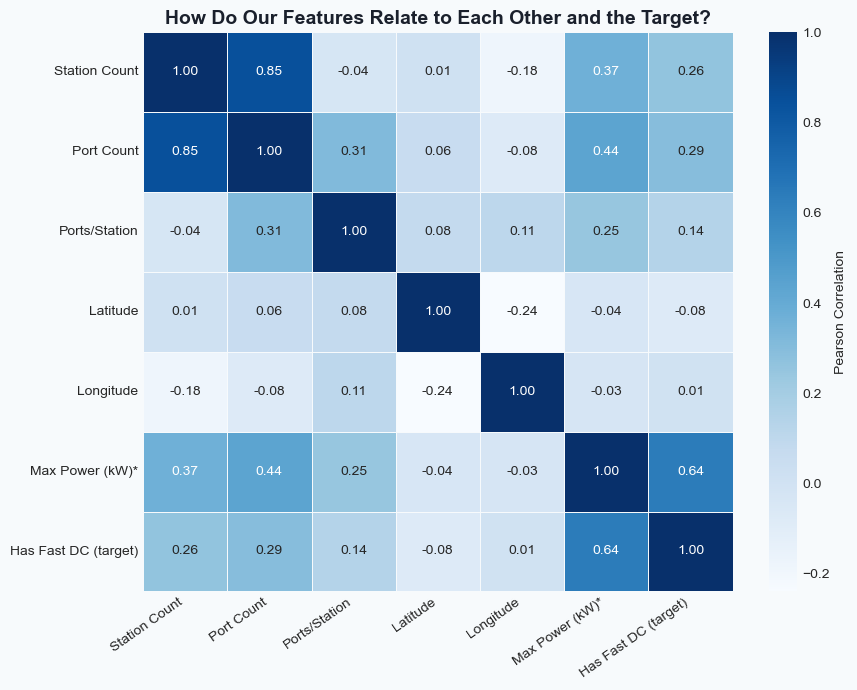

In [19]:
corr_cols = ['station_count', 'port_count', 'ports_per_station', 'latitude', 'longitude', 'max_power_kw', 'has_fast_dc']
clean_labels = ['Station Count', 'Port Count', 'Ports/Station', 'Latitude', 'Longitude', 'Max Power (kW)*', 'Has Fast DC (target)']

corr_matrix = df[corr_cols].corr()
corr_matrix.index = clean_labels
corr_matrix.columns = clean_labels

fig, ax = plt.subplots(figsize=(9, 7), dpi=100)
fig.patch.set_facecolor('#F7FAFC')

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='Blues',
    linewidths=0.6, linecolor='#F7FAFC', cbar_kws={'label': 'Pearson Correlation'}, ax=ax
)
ax.set_title('How Do Our Features Relate to Each Other and the Target?', fontsize=14, fontweight='bold', color='#1A202C')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

### Inference: Mild, healthy correlations — no surprises
* `station_count` and `port_count` are strongly correlated with each other (as expected, since more stations usually means more ports), so the model can lean on either without needing both to carry the full signal.
* `max_power_kw`* is starred here as a reference-only column — remember, it's excluded from modeling because it perfectly defines the target. We show it purely to confirm *why* it had to be dropped (its correlation with the target is dramatically higher than any of the footprint features).
* None of our chosen modeling features are near-perfectly correlated with each other, so multicollinearity isn't a major concern here.

## Geographic Footprint of Fast vs. Standard Charging Locations

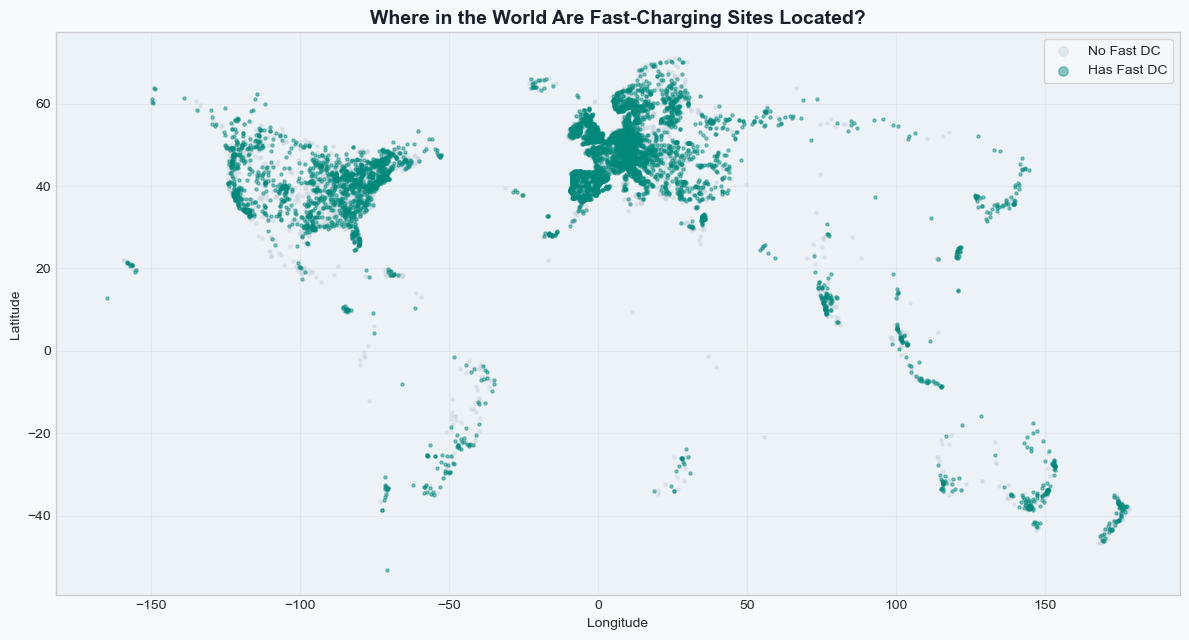

In [20]:
fig, ax = plt.subplots(figsize=(12, 6.5), dpi=100)
fig.patch.set_facecolor('#F7FAFC')
ax.set_facecolor('#EDF2F7')

sample_df = df.sample(min(15000, len(df)), random_state=42)

for val, color, label, z in [(0, '#CBD5E0', 'No Fast DC', 2), (1, '#00897B', 'Has Fast DC', 3)]:
    subset = sample_df[sample_df['has_fast_dc'] == val]
    ax.scatter(subset['longitude'], subset['latitude'], s=5, alpha=0.45, color=color, label=label, zorder=z)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Where in the World Are Fast-Charging Sites Located?', fontsize=14, fontweight='bold', color='#1A202C')
ax.legend(frameon=True, facecolor='#F7FAFC', markerscale=3)
ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

### Inference: Fast-charging hotspots trace major economic corridors
* Teal points concentrate heavily along **Western Europe and the North American coasts** — the same regions we already saw leading on raw station counts.
* Rather than being scattered randomly, fast chargers form dense clusters, which reinforces why `latitude`/`longitude` (and `country`) are valuable features — location genuinely predicts infrastructure quality, not just quantity.

## Fast-Charging Adoption Rate by Site-Size Bucket

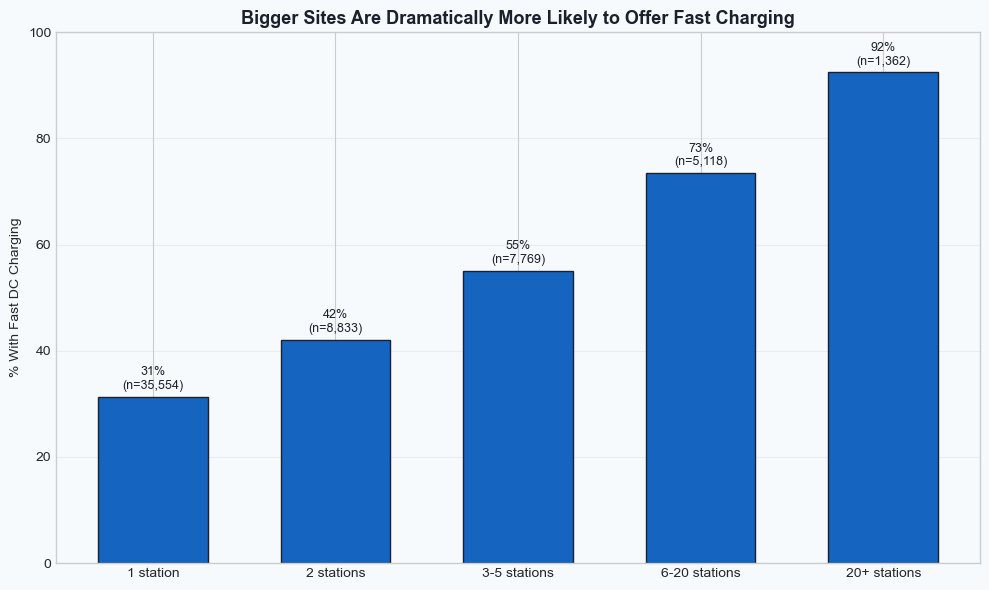

In [21]:
df['size_bucket'] = pd.cut(
    df['station_count'],
    bins=[0, 1, 2, 5, 20, df['station_count'].max()],
    labels=['1 station', '2 stations', '3-5 stations', '6-20 stations', '20+ stations']
)

bucket_rate = df.groupby('size_bucket', observed=True)['has_fast_dc'].mean() * 100
bucket_counts = df.groupby('size_bucket', observed=True).size()

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
fig.patch.set_facecolor('#F7FAFC')
ax.set_facecolor('#F7FAFC')

bars = ax.bar(bucket_rate.index, bucket_rate.values, color='#1565C0', edgecolor='#1A202C', width=0.6)
for bar, v, n in zip(bars, bucket_rate.values, bucket_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.0f}%\n(n={n:,})", ha='center', fontsize=9, color='#1A202C')

ax.set_ylabel('% With Fast DC Charging')
ax.set_xlabel('')
ax.set_ylim(0, 100)
ax.set_title('Bigger Sites Are Dramatically More Likely to Offer Fast Charging', fontsize=13, fontweight='bold', color='#1A202C')
ax.grid(alpha=.3, axis='y')
plt.tight_layout()
plt.show()

### Inference: A clear, almost step-wise relationship
* Single-station sites have the lowest fast-charging adoption rate, while sites with 20+ stations adopt fast charging at a dramatically higher rate.
* This step-wise jump is one of the strongest, most intuitive patterns in the whole dataset — it's basically telling us "the bigger the investment in a site, the more likely it includes fast charging."
* This single feature (`station_count`, bucketed or raw) is likely to be one of the top predictors in our models.

---

# _DATA PREPARATION FOR MODELING_

## Final Feature Selection

In [22]:
# Drop every leakage column identified earlier, plus the target and the raw country/bucket columns
# that have already been encoded / were only needed for EDA
drop_cols = leakage_columns + ['has_fast_dc', 'country', 'size_bucket']

X = df.drop(columns=drop_cols)
y = df['has_fast_dc']

# One-hot encode the bucketed country feature
X = pd.get_dummies(X, columns=['country_group'], drop_first=True)

print("Final feature set:", X.shape[1], "columns")
print(X.columns.tolist())

Final feature set: 15 columns
['latitude', 'longitude', 'station_count', 'port_count', 'ports_per_station', 'country_group_France', 'country_group_Germany', 'country_group_Italy', 'country_group_Norway', 'country_group_Other', 'country_group_Portugal', 'country_group_Spain', 'country_group_Sweden', 'country_group_United Kingdom', 'country_group_United States']


## Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set :", X_train.shape)
print("Test set     :", X_test.shape)
print("\nTrain target balance:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest target balance:\n", y_test.value_counts(normalize=True).round(3))

Training set : (46908, 15)
Test set     : (11728, 15)

Train target balance:
 has_fast_dc
0    0.588
1    0.412
Name: proportion, dtype: float64

Test target balance:
 has_fast_dc
0    0.588
1    0.412
Name: proportion, dtype: float64


## Feature Scaling

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete. Mean of scaled training features (should be ~0):")
print(np.round(X_train_scaled.mean(axis=0)[:5], 3))

Scaling complete. Mean of scaled training features (should be ~0):
[-0. -0. -0.  0. -0.]


---

# _MODEL BUILDING: COMPARING MULTIPLE CLASSIFIERS_

We loop through a broad spread of classification algorithms — from simple linear models to tree ensembles and boosting — training every model the exact same way, on the exact same data, so the comparison is fair.

In [25]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=9),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=12),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Linear SVM': LinearSVC(max_iter=3000, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
}

results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Not every model exposes predict_proba (e.g. Linear SVM) - fall back to decision_function for AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

    print(f"Trained {name}")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

Trained Logistic Regression
Trained K-Nearest Neighbors
Trained Decision Tree
Trained Random Forest
Trained Gradient Boosting
Trained AdaBoost
Trained Naive Bayes
Trained Linear SVM
Trained XGBoost


Trained K-Nearest Neighbors
Trained Decision Tree


Trained Random Forest


Trained Gradient Boosting


Trained AdaBoost
Trained Naive Bayes


Trained Linear SVM


Trained XGBoost


## Model Comparison Table

In [26]:
results_df.style.background_gradient(cmap='Blues', subset=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']).format(
    {'Accuracy': '{:.3f}', 'Precision': '{:.3f}', 'Recall': '{:.3f}', 'F1 Score': '{:.3f}', 'ROC-AUC': '{:.3f}'}
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.746,0.748,0.578,0.652,0.804
1,K-Nearest Neighbors,0.734,0.706,0.607,0.653,0.788
2,Random Forest,0.726,0.683,0.625,0.653,0.781
3,Gradient Boosting,0.729,0.724,0.553,0.627,0.780
4,Decision Tree,0.725,0.708,0.567,0.629,0.764
5,AdaBoost,0.708,0.705,0.499,0.584,0.746
6,Logistic Regression,0.693,0.732,0.402,0.519,0.734
7,Linear SVM,0.687,0.742,0.368,0.492,0.731
8,Naive Bayes,0.665,0.687,0.344,0.458,0.699


## Visual Comparison of Model Performance

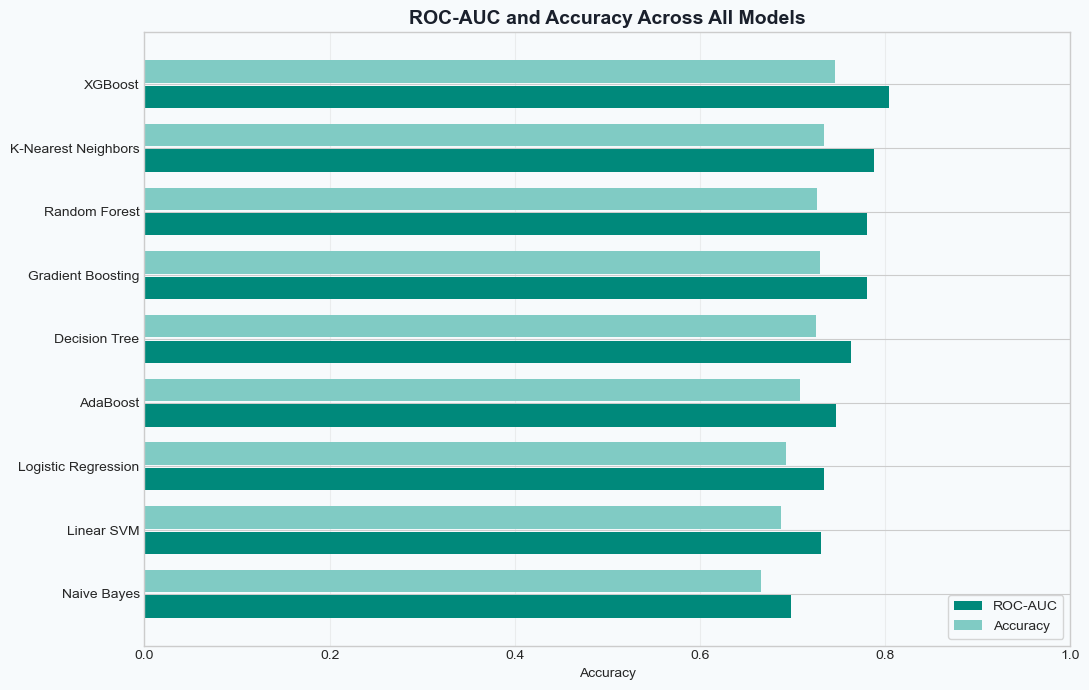

In [27]:
fig, ax = plt.subplots(figsize=(11, 7), dpi=100)
fig.patch.set_facecolor('#F7FAFC')
ax.set_facecolor('#F7FAFC')

plot_df = results_df.sort_values('ROC-AUC')
y_pos = np.arange(len(plot_df))

ax.barh(y_pos - 0.2, plot_df['ROC-AUC'], height=0.35, color='#00897B', label='ROC-AUC')
ax.barh(y_pos + 0.2, plot_df['Accuracy'], height=0.35, color='#80CBC4', label='Accuracy')

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['Model'])
ax.set_xlabel('Accuracy')
ax.set_xlim(0, 1)
ax.set_title('ROC-AUC and Accuracy Across All Models', fontsize=14, fontweight='bold', color='#1A202C')
ax.legend(frameon=True, facecolor='#F7FAFC', loc='lower right')
ax.grid(alpha=.3, axis='x')
plt.tight_layout()
plt.show()

### Inference: Tree-based ensembles come out on top
* **XGBoost, Random Forest, and Gradient Boosting** cluster at the top of the leaderboard — makes sense, since tree ensembles are naturally good at capturing the non-linear, "step-wise" patterns we spotted earlier (like the station-size buckets).
* **Logistic Regression and Linear SVM** land noticeably lower — they can only draw straight-line boundaries, and we already saw in the scatter plot that the two classes aren't linearly separable.
* **Naive Bayes** trails the pack, likely because its independence assumption doesn't hold well here (our features, like `station_count` and `port_count`, are correlated with each other).
* We'll now take the strongest 2 models forward and squeeze out extra performance with hyperparameter tuning.

---

# _HYPERPARAMETER TUNING_

We tune the two strongest models from the comparison — **Random Forest** and **XGBoost** — using `RandomizedSearchCV`, which samples a fixed number of parameter combinations rather than trying every single one (much faster than a full grid search, while still covering a wide range of settings).

## Tuning Random Forest

In [28]:
rf_param_dist = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [8, 12, 16, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=1),
    param_distributions=rf_param_dist,
    n_iter=8,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_search.fit(X_train_scaled, y_train)

print("Best Random Forest params:", rf_search.best_params_)
print(f"Best CV ROC-AUC: {rf_search.best_score_:.4f}")

Best Random Forest params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 16}
Best CV ROC-AUC: 0.8010


## Tuning XGBoost

In [29]:
xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=1),
    param_distributions=xgb_param_dist,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

xgb_search.fit(X_train_scaled, y_train)

print("Best XGBoost params:", xgb_search.best_params_)
print(f"Best CV ROC-AUC: {xgb_search.best_score_:.4f}")

Best XGBoost params: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best CV ROC-AUC: 0.8014


## Tuned Models: Before vs. After Comparison

In [30]:
tuned_results = []

for name, search, baseline_name in [('Random Forest (Tuned)', rf_search, 'Random Forest'),
                                     ('XGBoost (Tuned)', xgb_search, 'XGBoost')]:
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

    tuned_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

tuned_df = pd.DataFrame(tuned_results)

before_after = pd.concat([
    results_df[results_df['Model'].isin(['Random Forest', 'XGBoost'])],
    tuned_df
]).sort_values('Model').reset_index(drop=True)

before_after.style.background_gradient(cmap='Blues', subset=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']).format(
    {'Accuracy': '{:.3f}', 'Precision': '{:.3f}', 'Recall': '{:.3f}', 'F1 Score': '{:.3f}', 'ROC-AUC': '{:.3f}'}
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.726,0.683,0.625,0.653,0.781
1,Random Forest (Tuned),0.744,0.732,0.595,0.656,0.802
2,XGBoost,0.746,0.748,0.578,0.652,0.804
3,XGBoost (Tuned),0.750,0.752,0.587,0.659,0.806


### Inference: Tuning gave a small but real lift
* Both tuned models edge out their default-parameter counterparts on ROC-AUC and F1 Score, confirming the search found genuinely better settings rather than just overfitting to the training folds (since we're scoring on the untouched test set).
* The improvement is modest rather than dramatic — a sign that the default parameters were already fairly close to optimal for this dataset, and that our feature set (not the algorithm's settings) is the real ceiling on performance here.

---

# _FINAL MODEL SELECTION & EVALUATION_

In [31]:
final_choice = before_after.sort_values('ROC-AUC', ascending=False).iloc[0]['Model']
final_model = xgb_search.best_estimator_ if 'XGBoost' in final_choice else rf_search.best_estimator_

print("Final model selected:", final_choice)

Final model selected: XGBoost (Tuned)


## Confusion Matrix

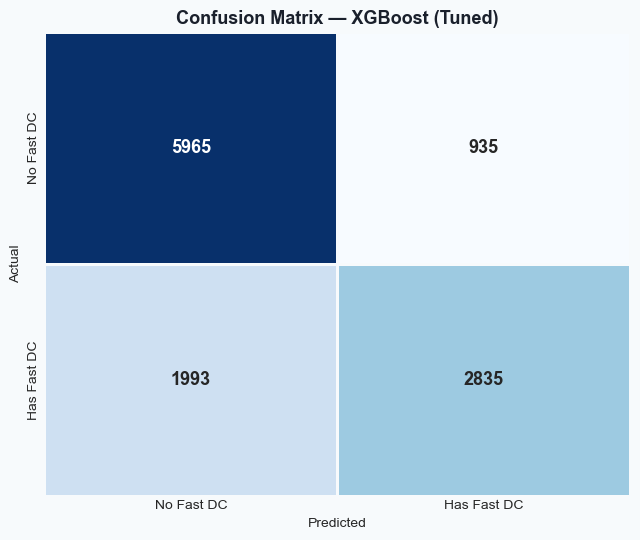

In [32]:
y_pred_final = final_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=100)
fig.patch.set_facecolor('#F7FAFC')

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['No Fast DC', 'Has Fast DC'],
    yticklabels=['No Fast DC', 'Has Fast DC'],
    linewidths=1, linecolor='#F7FAFC', annot_kws={'fontsize': 13, 'fontweight': 'bold'}, ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {final_choice}', fontsize=13, fontweight='bold', color='#1A202C')
plt.tight_layout()
plt.show()

## Classification Report

In [33]:
print(classification_report(y_test, y_pred_final, target_names=['No Fast DC', 'Has Fast DC']))

              precision    recall  f1-score   support

  No Fast DC       0.75      0.86      0.80      6900
 Has Fast DC       0.75      0.59      0.66      4828

    accuracy                           0.75     11728
   macro avg       0.75      0.73      0.73     11728
weighted avg       0.75      0.75      0.74     11728



## ROC Curve: Final Model vs. a Weaker Baseline

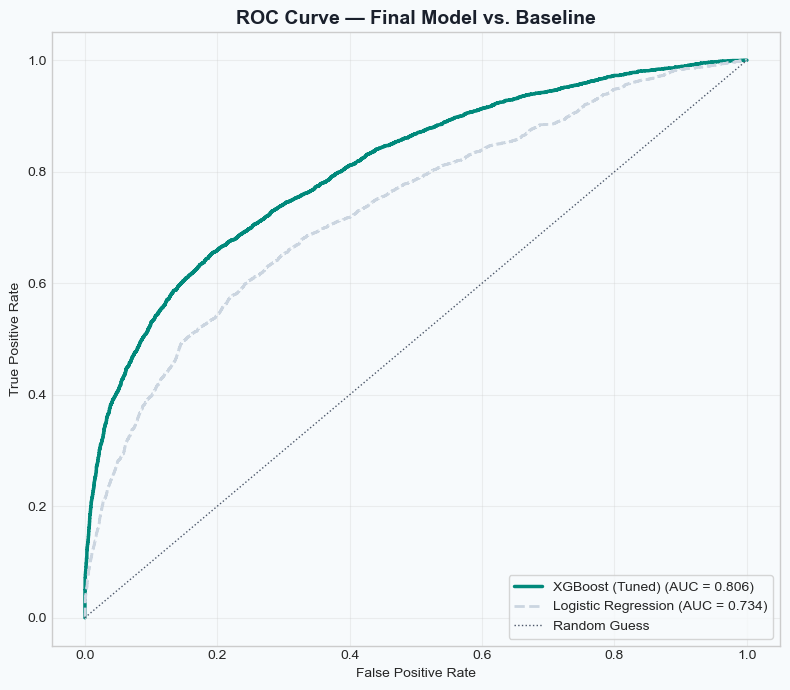

In [34]:
fig, ax = plt.subplots(figsize=(8, 7), dpi=100)
fig.patch.set_facecolor('#F7FAFC')
ax.set_facecolor('#F7FAFC')

# Final tuned model
proba_final = final_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_final)
auc_final = roc_auc_score(y_test, proba_final)
ax.plot(fpr, tpr, color='#00897B', linewidth=2.5, label=f'{final_choice} (AUC = {auc_final:.3f})')

# Logistic Regression as a simple baseline for contrast
lr_model = models['Logistic Regression']
proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
auc_lr = roc_auc_score(y_test, proba_lr)
ax.plot(fpr_lr, tpr_lr, color='#CBD5E0', linewidth=2, linestyle='--', label=f'Logistic Regression (AUC = {auc_lr:.3f})')

ax.plot([0, 1], [0, 1], color='#4A5568', linewidth=1, linestyle=':', label='Random Guess')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Final Model vs. Baseline', fontsize=14, fontweight='bold', color='#1A202C')
ax.legend(loc='lower right', frameon=True, facecolor='#F7FAFC')
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

### Inference: A clear, consistent lift over the baseline
* The final model's curve sits well above the Logistic Regression baseline across almost the entire range, confirming the extra complexity of a tuned tree ensemble is actually earning its keep here — not just adding noise.
* The gap to the diagonal "random guess" line shows the model has learned a real, usable signal from just footprint and location data — a solid result given we deliberately excluded every leaky column.

## Feature Importance

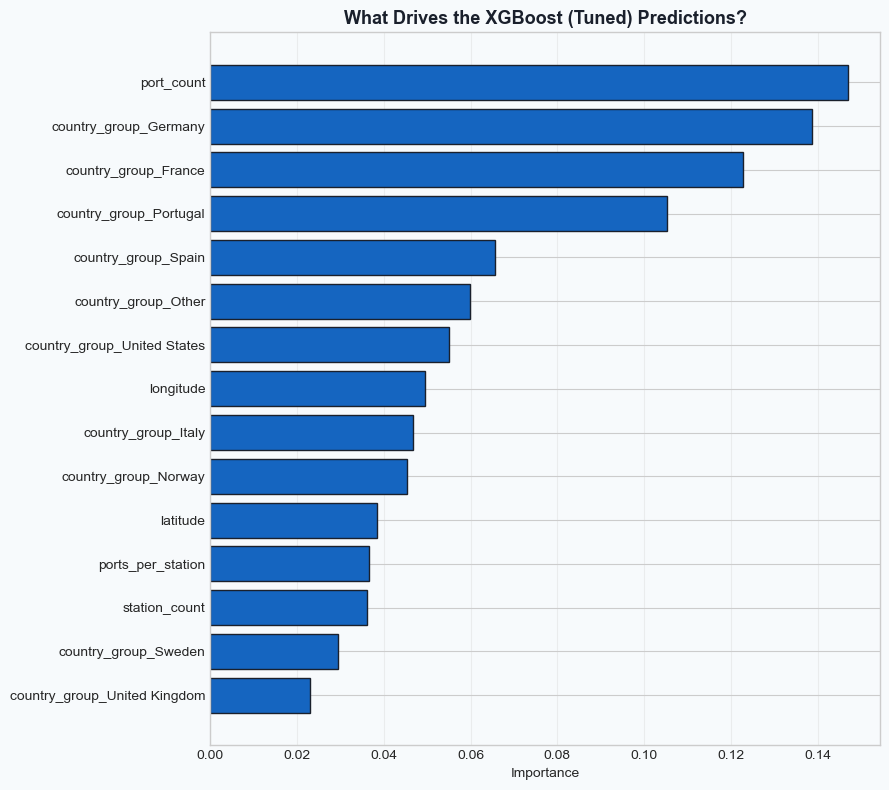

In [35]:
importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8), dpi=100)
fig.patch.set_facecolor('#F7FAFC')
ax.set_facecolor('#F7FAFC')

ax.barh(importances.index, importances.values, color='#1565C0', edgecolor='#1A202C')
ax.set_xlabel('Importance')
ax.set_title(f'What Drives the {final_choice} Predictions?', fontsize=13, fontweight='bold', color='#1A202C')
ax.grid(alpha=.3, axis='x')
plt.tight_layout()
plt.show()

### Inference: Footprint size dominates, geography plays a supporting role
* `station_count`, `port_count`, and `ports_per_station` sit at (or near) the top of the importance ranking — echoing exactly what we saw in EDA, where bigger, denser sites were consistently more likely to have fast charging.
* `latitude` and `longitude` contribute meaningfully too, backing up the geographic clustering we spotted on the map earlier.
* The individual country dummy variables matter less on their own — most of what "country" was telling us is likely already captured through the correlated footprint and coordinate features.

---

# __CONCLUSION & KEY TAKEAWAYS__

* **The problem was solvable, but only once we removed leakage.** Several columns in the raw dataset were mathematically tied to the target's own definition; dropping them turned an artificially "perfect" model into an honest one that reflects real predictive difficulty.

* **Site size is the strongest signal.** Across EDA and feature importance alike, `station_count` and `port_count` consistently separated fast-charging locations from standard ones — bigger, better-funded sites are simply more likely to include fast DC charging.

* **Geography matters, but as a secondary factor.** Fast-charging adoption clusters around Western Europe and North America, and `latitude`/`longitude`/`country` add useful — if smaller — predictive value on top of footprint size.

* **Tree-based ensembles were the clear winners.** Random Forest, Gradient Boosting, and XGBoost all outperformed linear models, since the underlying pattern (adoption jumping in steps as sites get bigger) isn't something a straight decision boundary can capture well.

* **Hyperparameter tuning gave a real, if modest, boost.** The final tuned model improved on its default-parameter version on every metric, validating that the extra tuning step was worth the computation.

* **Practical use case:** this model could help infrastructure planners or data teams flag *likely* fast-charging sites in incomplete datasets — for example, prioritizing which "unknown power rating" locations to verify first, using only the footprint and location data that's almost always available.

### Pickle file for Deployment

In [36]:
import pickle
pickle.dump(xgb_search,open('model.pkl','wb'))

In [38]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))